In [ ]:
from vae_project.imports import *
from vae_project import *
from vae_project.utils import *

In [ ]:
bs = 32

In [ ]:
transforms = [tv.transforms.Pad(2)] # pad to 32x32 to match decoder output
train_ds, val_ds = get_dataset("../data", transforms=transforms), get_dataset('../data', train=False, transforms=transforms)
train_dl = DataLoader(train_ds, bs)
val_dl = DataLoader(val_ds, bs*2)
xb, yb = next(iter(train_dl))

<Axes: >

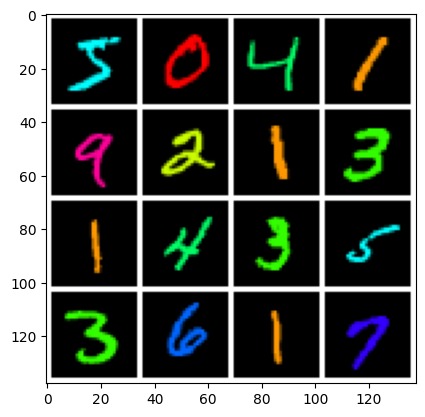

In [ ]:
show_imgs(xb[:16])

In [ ]:
def vae_loss(recon_x, x, mu, log_var, beta=1.0):
    bs = recon_x.shape[0]
    bce = F.binary_cross_entropy(recon_x.reshape(bs, -1), x.reshape(bs, -1), reduction='sum') / bs
    kld = -0.5 * t.sum(1 + log_var - mu.pow(2) - log_var.exp(), dim=1)
    return bce + beta*kld.mean(0)

Starting VAE training on cpu for 3 epochs...


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 1/3 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/3 [Valid]:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/3 | Train Loss: 511.0505 | Val Loss: 352.0393


...

Epoch 2/3 [Valid]:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2/3 | Train Loss: 310.0042 | Val Loss: 274.0455


Epoch 3/3 [Train]:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 3/3 [Valid]:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 3/3 | Train Loss: 260.5059 | Val Loss: 250.2858
Training finished.


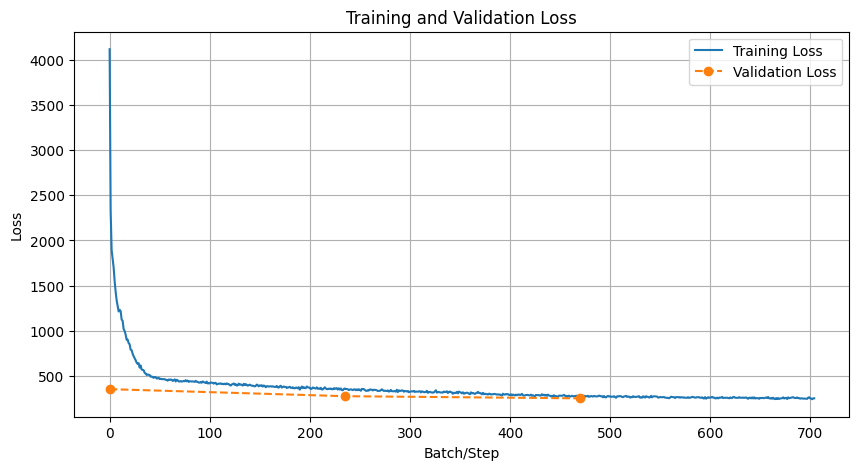

In [ ]:
epochs = 3
bs = 256
lr = 1e-3
latent_dim = 10
channels = [3, 8, 16, 64, 128]

train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=bs*2)

model = VAE(channels, input_size=(32, 32), latent_dim=latent_dim)
optimizer = optim.Adam(model.parameters(), lr=lr)
metrics_hook = MetricsHook()

trainer = Trainer(model, train_dl, val_dl, optimizer, vae_loss, epochs=epochs, hooks=[metrics_hook])
print(f"Starting VAE training on {trainer.device} for {epochs} epochs...")
trainer.fit()
print("Training finished.")

metrics_hook.plot_loss()

<Axes: >

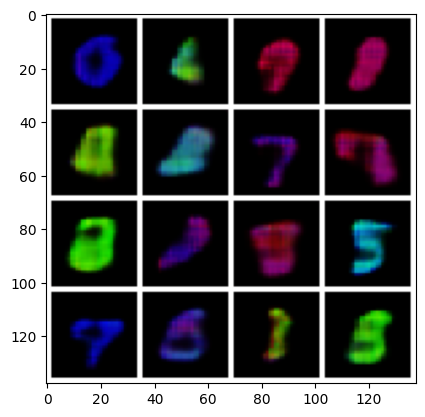

In [ ]:
show_imgs(model.sample(16))